# 🎬 YT8M Genre Classifier
**Stage 1** — Загрузка и подготовка данных из YouTube-8M

12 жанров: Gaming, Music, Animation, Vehicles, Sports, Animals, Food, Dance, Performance, Tech, Beauty, Film/Trailer

In [1]:
# ============================================================
# STAGE 1.0 — Импорты и конфигурация
# ============================================================
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter
import csv, json, warnings
warnings.filterwarnings('ignore')

# ── Пути ─────────────────────────────────────────────────────
BASE_DIR   = Path(r'C:\src\ai\video_classifier\data2')
DATA_DIR   = BASE_DIR / 'video' / 'validate'
VOCAB_PATH = BASE_DIR / 'vocabulary_full.csv'
OUT_DIR    = BASE_DIR / 'processed'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Маппинг YT8M label_id → наш жанр ─────────────────────────
LABEL_MAP = {
    # 🎮 Gaming
    0:  'Gaming',   1:  'Gaming',   27: 'Gaming',
    35: 'Gaming',   36: 'Gaming',   42: 'Gaming',   81: 'Gaming',
    # 🎵 Music
    3:  'Music',    4:  'Music',    9:  'Music',    10: 'Music',
    13: 'Music',    14: 'Music',    28: 'Music',    31: 'Music',
    33: 'Music',    34: 'Music',    37: 'Music',    38: 'Music',
    40: 'Music',    41: 'Music',    86: 'Music',
    # 🎨 Animation
    5:  'Animation', 16: 'Animation',
    # 🚗 Vehicles
    2:  'Vehicles', 7:  'Vehicles', 17: 'Vehicles', 19: 'Vehicles',
    30: 'Vehicles', 44: 'Vehicles', 45: 'Vehicles',
    # ⚽ Sports
    12: 'Sports',   43: 'Sports',   82: 'Sports',
    # 🐾 Animals
    15: 'Animals',  18: 'Animals',
    # 🍳 Food
    11: 'Food',     20: 'Food',     22: 'Food',
    29: 'Food',     32: 'Food',
    # 💃 Dance
    8:  'Dance',
    # 🎭 Performance
    6:  'Performance',
    # 📱 Tech
    21: 'Tech',     23: 'Tech',     24: 'Tech',
    # 💄 Beauty
    39: 'Beauty',
    # 🎬 Film/Trailer
    25: 'Film',
}

GENRES     = sorted(set(LABEL_MAP.values()))  # 12 жанров
GENRE2IDX  = {g: i for i, g in enumerate(GENRES)}
IDX2GENRE  = {i: g for g, i in GENRE2IDX.items()}

print(f'📂 DATA_DIR : {DATA_DIR}')
print(f'💾 OUT_DIR  : {OUT_DIR}')
print(f'🎬 Жанры ({len(GENRES)}): {GENRES}')
print(f'\nGENRE2IDX:')
for g, i in GENRE2IDX.items():
    print(f'   {i:>2}  {g}')

📂 DATA_DIR : C:\src\ai\video_classifier\data2\video\validate
💾 OUT_DIR  : C:\src\ai\video_classifier\data2\processed
🎬 Жанры (12): ['Animals', 'Animation', 'Beauty', 'Dance', 'Film', 'Food', 'Gaming', 'Music', 'Performance', 'Sports', 'Tech', 'Vehicles']

GENRE2IDX:
    0  Animals
    1  Animation
    2  Beauty
    3  Dance
    4  Film
    5  Food
    6  Gaming
    7  Music
    8  Performance
    9  Sports
   10  Tech
   11  Vehicles


In [2]:
# ============================================================
# STAGE 1.1 — Парсинг TFRecord → numpy arrays
# ============================================================
# Стратегия мультилейбл:
#   Берём первый лейбл из LABEL_MAP (по порядку приоритета).
#   Если ни один лейбл не в LABEL_MAP — пропускаем видео.
#   Если несколько лейблов в LABEL_MAP — берём тот, у которого
#   жанр встречается реже (балансировка приоритетов).

tfrecord_files = sorted(DATA_DIR.glob('*.tfrecord'))
print(f'📂 Файлов: {len(tfrecord_files)}')

# Приоритет жанров (редкие — выше, чтобы не тонули в Gaming/Music)
GENRE_PRIORITY = {
    'Beauty'     : 0,   # самый редкий → наивысший приоритет
    'Film'       : 1,
    'Dance'      : 2,
    'Animals'    : 3,
    'Sports'     : 4,
    'Tech'       : 5,
    'Performance': 6,
    'Food'       : 7,
    'Animation'  : 8,
    'Vehicles'   : 9,
    'Music'      : 10,
    'Gaming'     : 11,  # самый частый → наименьший приоритет
}

X_visual_list = []
X_audio_list  = []
y_list        = []
skipped       = 0

for file_idx, tf_file in enumerate(tfrecord_files):
    ds = tf.data.TFRecordDataset(str(tf_file))
    for raw in ds:
        example = tf.train.Example()
        example.ParseFromString(raw.numpy())
        feat = example.features.feature

        # Извлекаем метки
        lbls = list(feat['labels'].int64_list.value)

        # Находим все жанры для этого видео
        matched_genres = [LABEL_MAP[l] for l in lbls if l in LABEL_MAP]

        if not matched_genres:
            skipped += 1
            continue

        # Выбираем жанр с наивысшим приоритетом (наименьший номер)
        best_genre = min(matched_genres, key=lambda g: GENRE_PRIORITY[g])
        genre_idx  = GENRE2IDX[best_genre]

        # Извлекаем признаки
        rgb   = np.array(feat['mean_rgb'].float_list.value,   dtype=np.float32)  # (1024,)
        audio = np.array(feat['mean_audio'].float_list.value, dtype=np.float32)  # (128,)

        X_visual_list.append(rgb)
        X_audio_list.append(audio)
        y_list.append(genre_idx)

    if (file_idx + 1) % 50 == 0:
        print(f'   [{file_idx+1}/{len(tfrecord_files)}] '
              f'собрано: {len(y_list):>6} видео  пропущено: {skipped}')

# Конвертируем в numpy
X_visual = np.vstack(X_visual_list)   # (N, 1024)
X_audio  = np.vstack(X_audio_list)    # (N, 128)
y        = np.array(y_list, dtype=np.int64)

print(f'\n✅ Готово!')
print(f'   X_visual : {X_visual.shape}  dtype={X_visual.dtype}')
print(f'   X_audio  : {X_audio.shape}  dtype={X_audio.dtype}')
print(f'   y        : {y.shape}  dtype={y.dtype}')
print(f'   Пропущено: {skipped} видео (нет меток из нашего маппинга)')

📂 Файлов: 362
   [50/362] собрано:  11044 видео  пропущено: 3639
   [100/362] собрано:  22138 видео  пропущено: 7218
   [150/362] собрано:  33004 видео  пропущено: 10839
   [200/362] собрано:  44057 видео  пропущено: 14443
   [250/362] собрано:  54887 видео  пропущено: 17936
   [300/362] собрано:  65799 видео  пропущено: 21473
   [350/362] собрано:  76673 видео  пропущено: 24996

✅ Готово!
   X_visual : (79334, 1024)  dtype=float32
   X_audio  : (79334, 128)  dtype=float32
   y        : (79334,)  dtype=int64
   Пропущено: 25813 видео (нет меток из нашего маппинга)


  РАСПРЕДЕЛЕНИЕ КЛАССОВ  (N=79,334)
  Жанр                  N      %   Bar
  ────────────────────────────────────────────────────
  Animals           3,556    4.5%  █
  Animation         6,818    8.6%  ███
  Beauty            1,131    1.4%  
  Dance             5,006    6.3%  ██
  Film              1,672    2.1%  
  Food              3,702    4.7%  █
  Gaming           17,424   22.0%  ████████
  Music            16,838   21.2%  ████████
  Performance       3,564    4.5%  █
  Sports            4,553    5.7%  ██
  Tech              2,296    2.9%  █
  Vehicles         12,774   16.1%  ██████
  Imbalance ratio: 15.4×


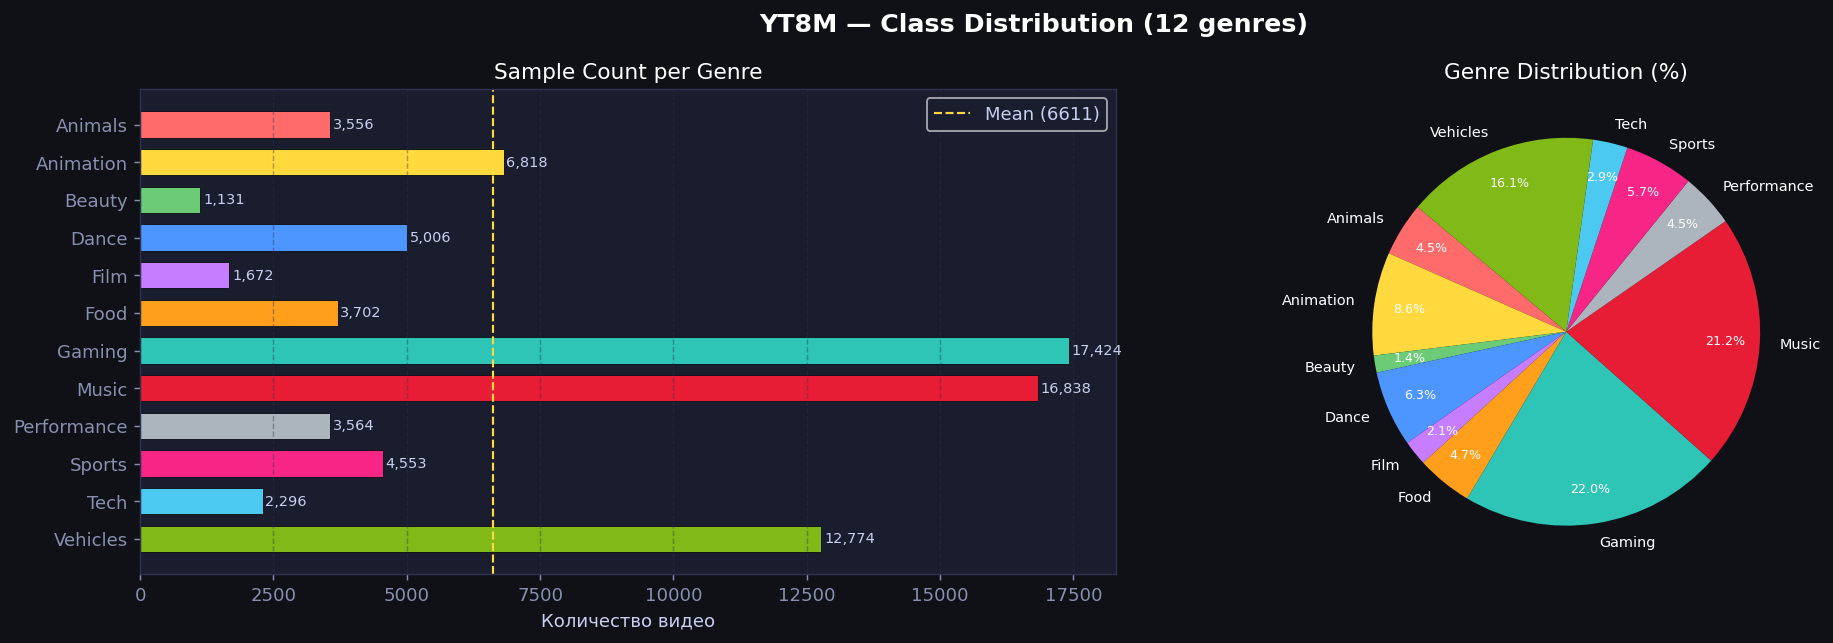

💾 Сохранено: class_distribution.png


In [3]:
# ============================================================
# STAGE 1.2 — Статистика и визуализация распределения классов
# ============================================================
counts  = np.bincount(y, minlength=len(GENRES))
N       = len(y)
freqs   = counts / N
imb     = counts.max() / counts.min()

print('=' * 60)
print(f'  РАСПРЕДЕЛЕНИЕ КЛАССОВ  (N={N:,})')
print('=' * 60)
print(f'  {"Жанр":<14}  {"N":>7}  {"% ":>6}  Bar')
print('  ' + '─' * 52)
for i, genre in enumerate(GENRES):
    bar = '█' * int(freqs[i] * 40)
    print(f'  {genre:<14}  {counts[i]:>7,}  {freqs[i]*100:>5.1f}%  {bar}')
print('=' * 60)
print(f'  Imbalance ratio: {imb:.1f}×')

# ── График ───────────────────────────────────────────────────
PALETTE = [
    '#FF6B6B','#FFD93D','#6BCB77','#4D96FF','#C77DFF',
    '#FF9F1C','#2EC4B6','#E71D36','#ACB5BD','#F72585',
    '#4CC9F0','#80B918'
]
plt.rcParams.update({
    'figure.facecolor':'#0F1117','axes.facecolor':'#1A1D2E',
    'axes.edgecolor':'#2E3250','axes.labelcolor':'#C8D0F0',
    'axes.titlecolor':'#FFFFFF','xtick.color':'#8890B0',
    'ytick.color':'#8890B0','text.color':'#C8D0F0',
    'grid.color':'#2E3250','grid.linestyle':'--','grid.alpha':0.4,
    'figure.dpi':130,
})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('YT8M — Class Distribution (12 genres)', 
             fontsize=14, color='white', fontweight='bold')

# Кол-во
ax = axes[0]
bars = ax.barh(GENRES, counts, color=PALETTE[:len(GENRES)],
               edgecolor='#0F1117', linewidth=0.5, height=0.7)
ax.set_xlabel('Количество видео')
ax.set_title('Sample Count per Genre')
ax.invert_yaxis()
ax.axvline(counts.mean(), color='#FFD93D', ls='--', lw=1.2,
           label=f'Mean ({counts.mean():.0f})')
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{cnt:,}', va='center', fontsize=8)
ax.legend(); ax.grid(axis='x')

# Проценты
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    counts, labels=GENRES, colors=PALETTE[:len(GENRES)],
    autopct='%1.1f%%', startangle=140,
    pctdistance=0.82,
    textprops={'fontsize': 8, 'color': 'white'},
)
for at in autotexts:
    at.set_fontsize(7)
ax.set_title('Genre Distribution (%)')

plt.tight_layout()
plt.savefig(OUT_DIR / 'class_distribution.png',
            bbox_inches='tight', facecolor='#0F1117')
plt.show()
print(f'💾 Сохранено: class_distribution.png')

In [4]:
# ============================================================
# STAGE 1.3 — Балансировка: cap на максимум сэмплов на класс
# ============================================================
# Проблема: Gaming(38K) vs Beauty(1.1K) = дисбаланс ~35×
# Решение: ограничиваем каждый класс до MAX_PER_CLASS
# Это уменьшит датасет но сделает его сбалансированным

MIN_COUNT    = counts.min()
MAX_PER_CLASS = min(5000, MIN_COUNT * 3)  # не более 5000 и не более 3× min
print(f'  Минимальный класс : {MIN_COUNT:,} видео')
print(f'  Cap per class     : {MAX_PER_CLASS:,} видео')

rng = np.random.default_rng(42)
keep_indices = []

for cls_idx in range(len(GENRES)):
    idx_cls = np.where(y == cls_idx)[0]
    if len(idx_cls) > MAX_PER_CLASS:
        idx_cls = rng.choice(idx_cls, MAX_PER_CLASS, replace=False)
    keep_indices.append(idx_cls)

keep_indices = np.concatenate(keep_indices)
rng.shuffle(keep_indices)  # перемешиваем

X_visual_bal = X_visual[keep_indices]
X_audio_bal  = X_audio[keep_indices]
y_bal        = y[keep_indices]

counts_bal = np.bincount(y_bal, minlength=len(GENRES))
print(f'\n  После балансировки:')
print(f'  {"Жанр":<14}  {"До":>7}  {"После":>7}')
print('  ' + '─' * 34)
for i, genre in enumerate(GENRES):
    print(f'  {genre:<14}  {counts[i]:>7,}  {counts_bal[i]:>7,}')
print(f'\n  Итого: {N:,} → {len(y_bal):,} видео')
print(f'  Новый imbalance: {counts_bal.max()/counts_bal.min():.2f}×')

  Минимальный класс : 1,131 видео
  Cap per class     : 3,393 видео

  После балансировки:
  Жанр                 До    После
  ──────────────────────────────────
  Animals           3,556    3,393
  Animation         6,818    3,393
  Beauty            1,131    1,131
  Dance             5,006    3,393
  Film              1,672    1,672
  Food              3,702    3,393
  Gaming           17,424    3,393
  Music            16,838    3,393
  Performance       3,564    3,393
  Sports            4,553    3,393
  Tech              2,296    2,296
  Vehicles         12,774    3,393

  Итого: 79,334 → 35,636 видео
  Новый imbalance: 3.00×


In [5]:
# ============================================================
# STAGE 1.4 — Проверка качества признаков
# ============================================================
print('📐 Статистика признаков (на сбалансированном датасете):')
print(f'  {"":<10}  {"min":>10}  {"max":>10}  {"mean":>10}  {"std":>10}')
print('  ' + '─' * 50)
for name, X in [("visual", X_visual_bal), ("audio", X_audio_bal)]:
    print(f'  {name:<10}  {X.min():>10.4f}  {X.max():>10.4f}  '
          f'{X.mean():>10.4f}  {X.std():>10.4f}')

# NaN/Inf проверка
for name, X in [("visual", X_visual_bal), ("audio", X_audio_bal)]:
    nan_count = np.isnan(X).sum()
    inf_count = np.isinf(X).sum()
    status = '✅' if nan_count == 0 and inf_count == 0 else '❌'
    print(f'  {status} {name}: NaN={nan_count}  Inf={inf_count}')

📐 Статистика признаков (на сбалансированном датасете):
                     min         max        mean         std
  ──────────────────────────────────────────────────
  visual         -1.9922      2.0078      0.0007      0.4514
  audio          -1.9922      2.0078      0.0019      0.6775
  ✅ visual: NaN=0  Inf=0
  ✅ audio: NaN=0  Inf=0


In [6]:
# ============================================================
# STAGE 1.5 — Сохранение
# ============================================================
np.save(OUT_DIR / 'X_visual.npy', X_visual_bal)
np.save(OUT_DIR / 'X_audio.npy',  X_audio_bal)
np.save(OUT_DIR / 'y.npy',        y_bal)

# Label map
label_map_df = pd.DataFrame([
    {'label_idx': i, 'category': g} for i, g in IDX2GENRE.items()
])
label_map_df.to_csv(OUT_DIR / 'label_map.csv', index=False)

# Config
config = {
    'n_samples'     : int(len(y_bal)),
    'n_classes'     : len(GENRES),
    'genres'        : GENRES,
    'genre2idx'     : GENRE2IDX,
    'dim_visual'    : int(X_visual_bal.shape[1]),
    'dim_audio'     : int(X_audio_bal.shape[1]),
    'max_per_class' : int(MAX_PER_CLASS),
    'imbalance_ratio': float(counts_bal.max()/counts_bal.min()),
    'label_map'     : LABEL_MAP,
    'genre_priority': GENRE_PRIORITY,
}
import json
with open(OUT_DIR / 'config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print('=' * 55)
print('       STAGE 1 — COMPLETE')
print('=' * 55)
print(f'  Видео   : {len(y_bal):,}')
print(f'  Классов : {len(GENRES)}')
print(f'  Дисбаланс: {counts_bal.max()/counts_bal.min():.2f}×')
print(f'  Visual  : {X_visual_bal.shape}')
print(f'  Audio   : {X_audio_bal.shape}')
print(f'\n💾 Сохранено в {OUT_DIR}:')
for f in sorted(OUT_DIR.iterdir()):
    print(f'   {f.name:<30} {f.stat().st_size/1024**2:.2f} MB')
print('=' * 55)
print('✅ Готово к Stage 2 — EDA')

       STAGE 1 — COMPLETE
  Видео   : 35,636
  Классов : 12
  Дисбаланс: 3.00×
  Visual  : (35636, 1024)
  Audio   : (35636, 128)

💾 Сохранено в C:\src\ai\video_classifier\data2\processed:
   class_distribution.png         0.12 MB
   config.json                    0.00 MB
   label_map.csv                  0.00 MB
   X_audio.npy                    17.40 MB
   X_visual.npy                   139.20 MB
   y.npy                          0.27 MB
✅ Готово к Stage 2 — EDA
